# Esame Laboratorio di Programmazione II - 11/09/2025


Scrivete chiaramente sul notebook il vostro nome e matricola e sul nome con cui salvate il file la vostra matricola.

Per ogni funzione e metodo che richiede un campionamento rispetto ad una distribuzione settate il seed a 0: ``np.random.seed(0)``.

Stampate il risultato delle domanda e consegnate il compito eseguito, quindi per cui ogni cella ha il corrispondente output.
Quindi ad esempio

e.g., 
NON scrivete: 
```python 
    lista=np.array([1,2,3])
```
ma 
```python
    lista=np.array([1,2,3]) 
    print('lista =', lista)   
```
Attenzione!Se scrivete:
```python
    lista=np.array([1,2,3])
    lista
```
``lista`` sarà l'unico ouput che si vede di quella cella

NB se l'output è una matrice molto grande non dovete stamparla.

Sarà valutata anche la presentazione, ad esempio un plot senza ettichette sugli assi o illleggibili sarà valutato meno bene di uno con ettichette chiare.

Commentate il compito di modo che si capisca cosa avete fatto.

Controllate attentamente di avere consegnato il file giusto.

In [ ]:
#Potete importare direttamente qui le librerie che userete

## Esercizio 1

Un’azienda ha registrato i **costi mensili di trasporto** (in euro) per 9 mezzi:  
450, 720, 1200, 980, 510, 1500, 640, 890, 2000  

1. Calcola la **spesa totale complessiva**.  

2. I mezzi con spesa **inferiore a 700 €** ricevono un **bonus di efficienza del 10%** (cioè la spesa viene ridotta del 10%).  

3. Stampa il **risparmio totale** ottenuto dall’azienda.


##### LEGGENDA 

- **np.array([...], dtype=float)** -> Crea un array NumPy di float

- **.sum()** -> Calcola la somma di tutti gli elementi

- **array < valore** -> Confronto vettoriale, restituisce un array di booleani

- **array.copy()** -> Crea una copia indipendente

- **array[mask] *= 0.9** -> Applica lo sconto del 10% (moltiplica per 0.9) solo agli elementi selezionati

In [ ]:
import numpy as np

# 1. Calcolo la spesa totale
costi = np.array ([450, 720, 1200, 980, 510, 1500, 640, 890, 2000], dtype = float)
print ("PUNTO 1:")
print ("- Costi originali:", costi.tolist())
totale_originale = costi.sum()
print(f"- Spesa totale complessiva: {totale_originale:.2f} €")


# 2. Applico lo sconto (10 %) a chi spende < 700
costi_bonus = costi.copy()
mask = costi_bonus < 700
costi_bonus[mask] *= 0.9
print ("\nPUNTO 2: ")
print ("- Costi dopo bonus (10 % di sconto):", np.round(costi_bonus, 2).tolist())


# 3. Calcolo risparmio totale
totale_bonus = costi_bonus.sum()
risparmio = totale_originale - totale_bonus
print ("\nPUNTO 3")
print (f"- Totale dopo il bonus: {totale_bonus:2f} €")
print (f"- Risparmio totale ottenuto dall'azienda: {risparmio:2f} €")

PUNTO 1:
- Costi originali: [450.0, 720.0, 1200.0, 980.0, 510.0, 1500.0, 640.0, 890.0, 2000.0]
- Spesa totale complessiva: 8890.00 €

PUNTO 2: 
- Costi dopo bonus (10 % di sconto): [405.0, 720.0, 1200.0, 980.0, 459.0, 1500.0, 576.0, 890.0, 2000.0]

PUNTO 3
- Totale dopo il bonus: 8730.000000 €
- Risparmio totale ottenuto dall'azienda: 160.000000 €


## Esercizio 2

Un’urna contiene **4 palline verdi** e **1 pallina gialla**.  
Dopo ogni estrazione la pallina viene **rimessa nell’urna**.  

1. Scrivi una funzione che simula **N estrazioni** e rappresenta i risultati con un array NumPy (`1 = verde`, `0 = gialla`).  

2. Calcola la **frequenza relativa** delle palline verdi e gialle dopo 20, 40, 60, …, 200 estrazioni.  

3. Rappresenta graficamente l’**andamento della frequenza relativa di verdi e gialle** in funzione del numero di estrazioni.


##### LEGGENDA

- **np.random.choice([1,0], size=N, p=[0.8,0.2])** -> Simula N estrazioni con reinserimento (1=verde, 0=gialla)

- **risultati[:step]** -> Selezione delle prime `step` estrazioni

- **.mean()** -> Calcola la proporzione di 1 (verdi)

- **plt.plot(steps, prop_..., marker = '...', label='...')** -> Traccia la linea con un marcatore per i punti

- **plt.grid(True)** -> Aggiunge una griglia al grafico





PUNTO 1 - Esempio con 10 estrazioni: [1, 1, 1, 1, 1, 1, 1, 0, 0, 1]

PUNTO 2 – Frequenze relative cumulative:
Dopo  20 estrazioni: verde = 0.750, gialla = 0.250
Dopo  40 estrazioni: verde = 0.850, gialla = 0.150
Dopo  60 estrazioni: verde = 0.850, gialla = 0.150
Dopo  80 estrazioni: verde = 0.850, gialla = 0.150
Dopo 100 estrazioni: verde = 0.850, gialla = 0.150
Dopo 120 estrazioni: verde = 0.833, gialla = 0.167
Dopo 140 estrazioni: verde = 0.821, gialla = 0.179
Dopo 160 estrazioni: verde = 0.806, gialla = 0.194
Dopo 180 estrazioni: verde = 0.817, gialla = 0.183
Dopo 200 estrazioni: verde = 0.825, gialla = 0.175

PUNTO 3 – Grafico dell'andamento:


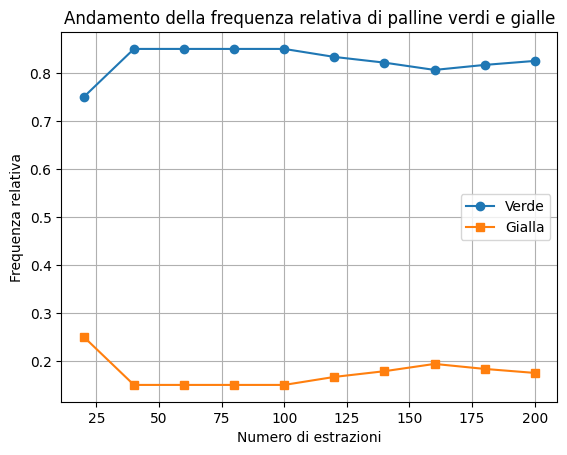

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Funzione che simula N estrazioni
def estrai(N):
    return np.random.choice ([1, 0], size = N, p = [4/5, 1/5])

np.random.seed(0)
print ("PUNTO 1 - Esempio con 10 estrazioni:" , estrai(10).tolist())


# 2. Frequenza relativa dopo 20,...,200 estrazioni
Nmax = 200
risultati = estrai(Nmax)                # Simulo tutte le 200 estrazioni

steps = list(range(20, Nmax+1, 20))      # 20,..., 200
prop_verdi = []
prop_gialli = []

for step in steps:
    prime_step = risultati[:step]
    prop_v = prime_step.mean()          # proporzione di 1 (verdi)
    prop_g = 1 - prop_v                 # proporzione di 0 (gialli)
    prop_verdi.append(prop_v)
    prop_gialli.append(prop_g)

print("\nPUNTO 2 – Frequenze relative cumulative:")
for s, pv, pg in zip(steps, prop_verdi, prop_gialli):
    print(f"Dopo {s:3d} estrazioni: verde = {pv:.3f}, gialla = {pg:.3f}")


# 3. Grafico dell'andamento
print("\nPUNTO 3 – Grafico dell'andamento:")
plt.plot (steps, prop_verdi, marker = 'o', label = 'Verde')         # Marker 'o' per i punti
plt.plot (steps, prop_gialli, marker = 's', label = 'Gialla')       # Marker 's' per i quadrati
plt.grid(True)                                                      # Aggiunge la griglia di sfondo
plt.xlabel ('Numero di estrazioni')
plt.ylabel ('Frequenza relativa')
plt.title ('Andamento della frequenza relativa di palline verdi e gialle')
plt.legend()
plt.show()

## Esercizio 3

1. Genera una matrice NumPy di dimensioni **5 x 7**, con valori interi casuali compresi tra 10 e 99 (inclusi).  

2. Per ogni riga, seleziona e stampa il **numero pari più grande**.  


##### LEGGENDA

- **np.random.randint(min, max+1, size)** -> Genera interi casuali (estremo superiore escluso, quindi +1)

- **riga % 2 == 0** -> Maschera per selezionare i numeri pari

- **np.max(array)** -> Valore massimo

- **if len(pari) > 0** -> Controllo se esistono numeri pari

In [22]:
import numpy as np

# 1. Genero la matrice
np.random.seed(0)
matrice = np.random.randint(10, 100, (5, 7))
print ("PUNTO 1 - Matrice generata:")
print (matrice)


# 2. Per ogni riga, numero pari più grande
print ("\nPUNTO 2 - Numero pari più grande per ogni riga:")
for i in range(5):
    riga = matrice[i]
    pari = riga[riga % 2 == 0]
    if len(pari) > 0:
        max_pari = np.max(pari)
        print (f"Riga {i+1}: {max_pari}")
    else:
        print(f"Riga {i+1}: Nessun numero pari")

PUNTO 1 - Matrice generata:
[[54 57 74 77 77 19 93]
 [31 46 97 80 98 98 22]
 [68 75 49 97 56 98 91]
 [47 35 87 82 19 30 90]
 [79 89 57 74 92 98 59]]

PUNTO 2 - Numero pari più grande per ogni riga:
Riga 1: 74
Riga 2: 98
Riga 3: 98
Riga 4: 90
Riga 5: 98


## Esercizio 4

Utilizza il dataset `tips.csv` (contiene colonne come `total_bill`, `tip`, `sex`, `smoker`, `day`, `time`, `size`).  

1. Conta i **valori mancanti per colonna** ed elimina le righe con valori mancanti.  

2. Crea una nuova colonna `tip_ratio` definita come:  

   \[
   \texttt{tip\_ratio} = \frac{\texttt{tip}}{\texttt{total\_bill}}
   \]  

   *(Indica la percentuale di mancia rispetto al conto totale).*  

3. **Filtra** i conti con:  
   - `total_bill` > 30  
   - `tip_ratio` > 0.15  

4. **Grafico a barre** dei **10 clienti con tip_ratio più alto** (usa l’indice del DataFrame come etichetta).  

5. **Scatter plot** con:  
   - x = `total_bill`  
   - y = `tip`  
   - colore dei punti = `tip_ratio`.  


#### LEGGENDA (Esercizio 4)

- **pd.read_csv('tips.csv')** -> Carica il dataset

- **df.isnull().sum()** -> Conta i valori mancanti per colonna

- **df.dropna()** -> Elimina righe con NaN

- **df['tip_ratio'] = df['tip'] / df['total_bill']** -> Crea colonna tip_ratio

- **df[(df['total_bill'] > 30) & (df['tip_ratio'] > 0.15)]** -> Filtro con due condizioni

- **df.nlargest(10, 'tip_ratio')** -> Restituisce le 10 righe con tip_ratio più alto

- **plt.bar(indici, valori)** -> Grafico a barre (indici del DataFrame come etichette)

- **plt.xticks(rotation=45)** -> Ruota le etichette per leggibilità

- **plt.scatter(x, y, c=colore)** -> Scatter plot con colore

- **plt.colorbar(label='...')** -> Barra dei colori

PUNTO 1:
- Dimensioni originali del database: (244, 7)
- Valori mancanti per colonna:
 total_bill    0
tip           1
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64
- Dimendioni dopo dropna: (243, 7)

PUNTO 2 - Prime 3 righe con tip_ratio:
   total_bill   tip  tip_ratio
0       16.99  1.01   0.059447
1       10.34  1.66   0.160542
2       21.01  3.50   0.166587

PUNTO 3 - Numero di conti che soddisfano i criteri: 8
     total_bill    tip  tip_ratio
23        39.42   7.58   0.192288
39        31.27   5.00   0.159898
44        30.40   5.60   0.184211
47        32.40   6.00   0.185185
83        32.68   5.00   0.152999
141       34.30   6.70   0.195335
170       50.81  10.00   0.196812
212       48.33   9.00   0.186220

PUNTO 4 - Grafico a barre dei top 10 tip_ratio


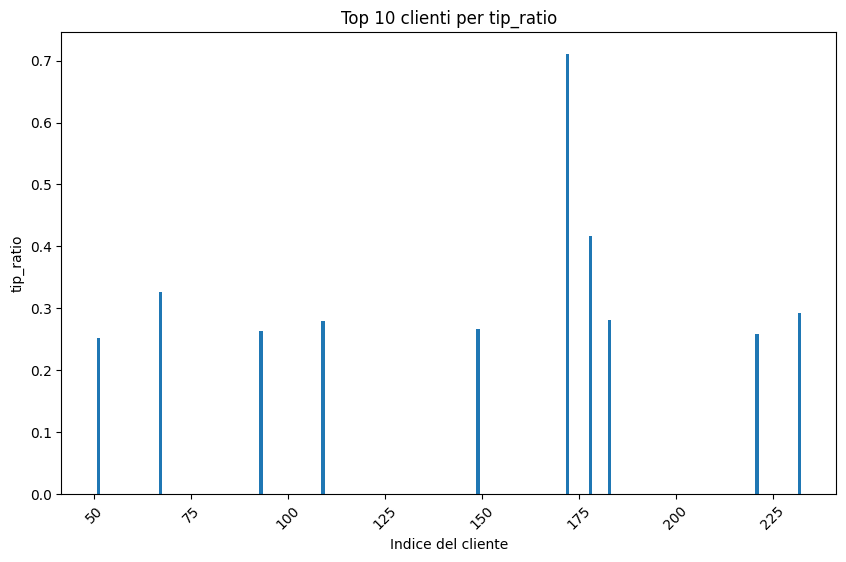


PUNTO 5 – Scatter plot total_bill vs tip (colore = tip_ratio)


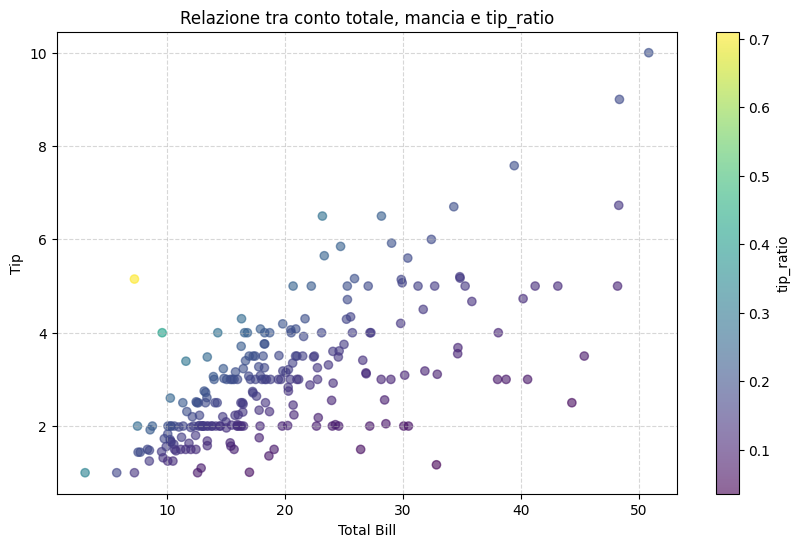

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carico, conto i NaN, elimino righe con NaN
df = pd.read_csv('tips.csv')
print ("PUNTO 1:")
print ("- Dimensioni originali del database:", df.shape)
print ("- Valori mancanti per colonna:\n", df.isnull().sum())

df = df.dropna()
print ("- Dimendioni dopo dropna:", df.shape)


# 2. Creo colonna tip_ratio
df['tip_ratio'] = df['tip'] / df['total_bill']
print ("\nPUNTO 2 - Prime 3 righe con tip_ratio:")
print (df[['total_bill', 'tip', 'tip_ratio']].head(3))


# 3. Filtro total_bill > 30 e tip_ratio > 0.15
filtro = df[(df['total_bill'] > 30) & (df['tip_ratio'] > 0.15)]
print(f"\nPUNTO 3 - Numero di conti che soddisfano i criteri: {len(filtro)}")
if len(filtro) > 0:
    print(filtro[['total_bill', 'tip', 'tip_ratio']].head(8))


# 4. Grafico a barre 
top_10 = df.nlargest (10, 'tip_ratio')
print ("\nPUNTO 4 - Grafico a barre dei top 10 tip_ratio")
plt.figure (figsize = (10,6))
plt.bar (top_10.index, top_10['tip_ratio'])
plt.xlabel ('Indice del cliente')
plt.ylabel ('tip_ratio')
plt.title ('Top 10 clienti per tip_ratio')
plt.xticks (rotation = 45)
plt.show()


# 5. Scatter plot
print("\nPUNTO 5 – Scatter plot total_bill vs tip (colore = tip_ratio)")
plt.figure(figsize=(10,6))
sc = plt.scatter(df['total_bill'], df['tip'], c=df['tip_ratio'], alpha=0.6)
plt.colorbar(sc, label='tip_ratio')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Relazione tra conto totale, mancia e tip_ratio')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## Esercizio 5

Utilizza il dataset `tips.csv`.  

1. Quante **righe e colonne** ha il dataset? Successivamente elimina la colonna `time` dal DataFrame.  
2. Trova il **giorno (`day`) più frequente** nel dataset.  
3. Calcola la **media del conto totale (`total_bill`) per ciascun giorno** e ordina i risultati.  
4. Crea un **boxplot** dei valori di `tip` raggruppati per giorno (`day`).  
5. Crea un **violin plot** della distribuzione del `tip_ratio` (mancia/conto) per ciascun giorno della settimana.  

Bonus (Per i punti 4 e 5 dividere i risultati anche per sesso)

#### LEGGENDA 

- **df.drop(columns=['col'])** -> Elimina una colonna

- **df['col'].value_counts().idxmax()** -> Valore più frequente

- **df.groupby('col')['val'].mean().sort_values()** -> Media per gruppo ordinata

- **sns.boxplot(x='col', y='val', data=df)** -> Boxplot

- **sns.boxplot(x='col', y='val', hue='sex', data=df)** -> Boxplot diviso per sesso

- **sns.violinplot(x='col', y='val', hue='sex', data=df)** -> Violin plot diviso per sesso

PUNTO 1:
- Righe: 243, Colonne: 8
- Colonne dopo eliminazione: 7

PUNTO 2:
- Giorno più frequente: Sat

PUNTO 3 - Media total_bill per giorno
day
Fri     17.151579
Thur    17.682742
Sat     20.441379
Sun     21.462667
Name: total_bill, dtype: float64

PUNTO 4 - Boxplot di tip per giorno


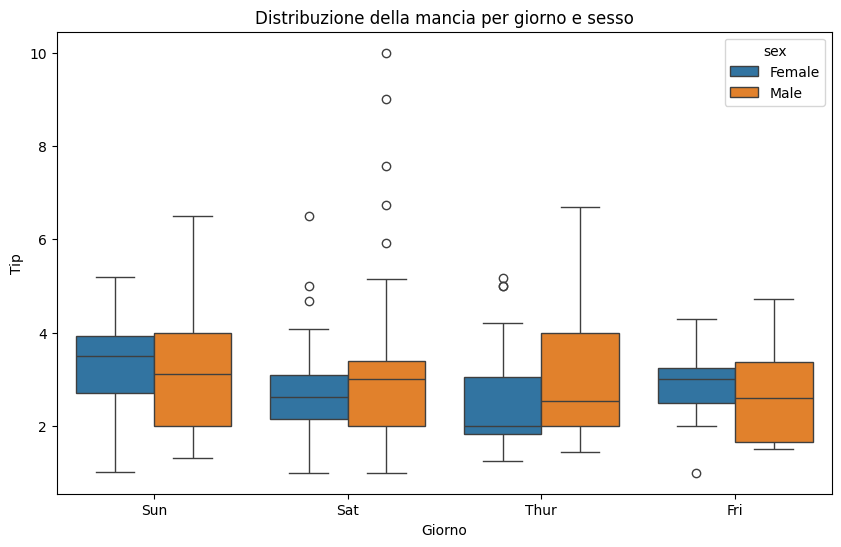


PUNTO 5 - Violin plot di tip-ratio per giorno


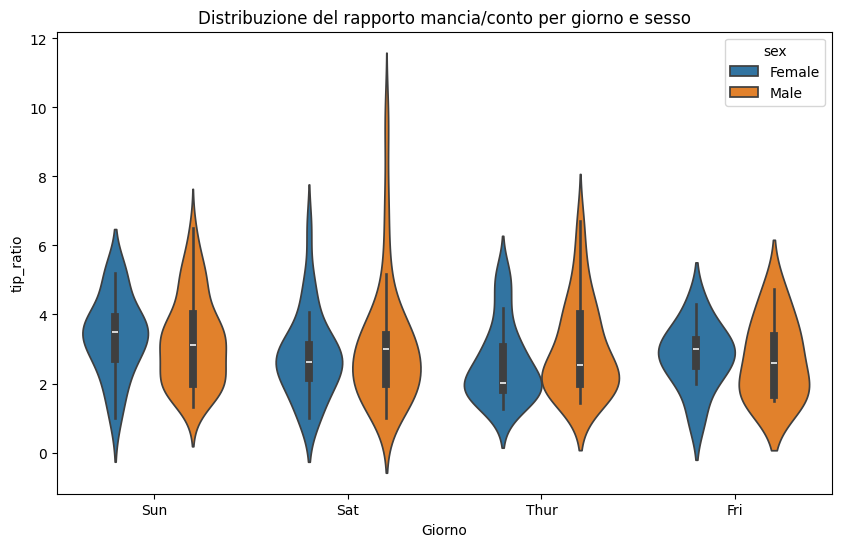

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carico il dataset e pulizia dei NaN 
df = pd.read_csv ('tips.csv')                       # Carico il database
df = df.dropna()                                    # Pulisco i NaN
df['tip_ratio'] = df['tip'] / df['total_bill']      # Creo colonna tip_ratio

# 1. Dimensioni database ed elimino colonna time
print ("PUNTO 1:")
print (f"- Righe: {df.shape[0]}, Colonne: {df.shape[1]}")
df = df.drop(columns = ['time'])
print (f"- Colonne dopo eliminazione: {df.shape[1]}")


# 2. Giorno più frequente
giorno_freq = df['day'].value_counts().idxmax()
print ("\nPUNTO 2:")
print (f"- Giorno più frequente: {giorno_freq}")


# 3. Media total_bill per giorno (ordinata)
media_giorno = df.groupby('day')['total_bill'].mean().sort_values()
print ("\nPUNTO 3 - Media total_bill per giorno")
print (media_giorno)


# 4. Boxplot
print ("\nPUNTO 4 - Boxplot di tip per giorno")
plt.figure (figsize = (10, 6))
sns.boxplot (x = 'day', y = 'tip', hue = 'sex', data=df)
plt.xlabel ('Giorno')
plt.ylabel ('Tip')
plt.title ('Distribuzione della mancia per giorno e sesso')
plt.show ()


# 4. Violin Plot
print ("\nPUNTO 5 - Violin plot di tip-ratio per giorno")
plt.figure (figsize = (10, 6))
sns.violinplot (x = 'day', y = 'tip', hue = 'sex', data=df)
plt.xlabel ('Giorno')
plt.ylabel ('tip_ratio')
plt.title ('Distribuzione del rapporto mancia/conto per giorno e sesso')
plt.show ()

## Esercizio 6

Hai a disposizione il dataset di coppie `(x, y)` qui sotto riportato.  

1. Stima i parametri della retta del tipo  

   \[
   y = a \cdot x + b
   \]  

2. Plotta i punti originali e la retta ottenuta.  

3. Calcola **MAE** (Mean Absolute Error) e **RMSE** (Root Mean Squared Error) tra i valori reali `y` e quelli stimati dal modello, dove:  

   $$
   \text{MAE} = \frac{1}{n}\sum_{i=1}^{n} \lvert y_i - \hat{y}_i \rvert
   $$  

   $$
   \text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
   $$  

#### LEGGENDA 

- **np.linspace(0, 10, 30)** -> Crea 30 punti equidistanti tra 0 e 10

- **np.random.normal(0, 1.5, 30)** -> Genera 30 errori casuali con media 0 e std 1.5

- **def modello_lineare(x, a, b): return a*x + b** -> Modello lineare per curve_fit

- **curve_fit(modello, x, y)** -> Restituisce parametri ottimali (popt) e matrice di covarianza (pcov)

- **mean_absolute_error(y, y_pred)** -> Calcola MAE

- **np.sqrt(mean_squared_error(y, y_pred))** -> Calcola RMSE

- **plt.scatter(x, y)** -> Grafico a punti (dati osservati)

- **plt.plot(x, y_pred, 'r-')** -> Grafico della retta stimata

PUNTO 1
Parametri stimati: a = 2.3841, b = 4.2437

PUNTO 2 - Grafico


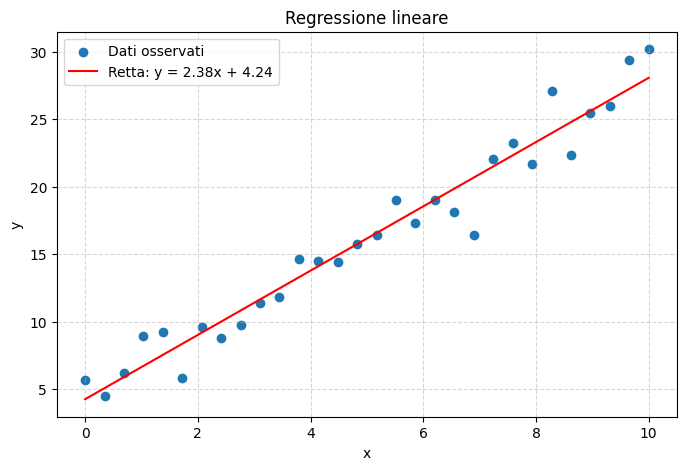


PUNTO 3
MAE = 1.2264
RMSE = 1.5855


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Creo i dati e stimo i parametri
np.random.seed(0)
x = np.linspace(0, 10, 30)
y = 2.5 * x + 3 + np.random.normal(0, 1.5, 30)   # y = 2.5x + 3 + rumore

def modello_lineare(x, a, b):
    return a * x + b

popt, pcov = curve_fit(modello_lineare, x, y)
a, b = popt
print("PUNTO 1")
print(f"Parametri stimati: a = {a:.4f}, b = {b:.4f}")


# 2. Grafico punti e retta
print("\nPUNTO 2 - Grafico")
y_pred = modello_lineare(x, a, b)

plt.figure(figsize=(8,5))
plt.scatter(x, y, label='Dati osservati')
plt.plot(x, y_pred, 'r-', label=f'Retta: y = {a:.2f}x + {b:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regressione lineare')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# 3.  MAE e RMSE
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
print("\nPUNTO 3")
print(f"MAE = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
